# Game of Thrones
Explore deaths and battles from this fantasy world

# Context
Game of Thrones is a hit fantasy tv show based on the equally famous book series "A Song of Fire and Ice" by George RR Martin. The show is well known for its vastly complicated political landscape, large number of characters, and its frequent character deaths.

# Content
This dataset combines three sources of data, all of which are based on information from the book series.

Firstly, there is battles.csv which contains Chris Albon's "The War of the Five Kings" Dataset. Its a great collection of all of the battles in the series.

Secondly we have character-deaths.csv from Erin Pierce and Ben Kahle. This dataset was created as a part of their Bayesian Survival Analysis.

Finally we have a more comprehensive character dataset with character-predictions.csv. It includes their predictions on which character will die

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
#Read File
game = pd.read_csv(r"C:\Users\RAJAT SAHU\Desktop\DataScirce\GameOfThrone\battles.csv")
btl.head(2)

,name,year,battle_number,attacker_king,defender_king,attacker_1,attacker_2,attacker_3,attacker_4,defender_1,...,major_death,major_capture,attacker_size,defender_size,attacker_commander,defender_commander,summer,location,region,note
0,Battle of the Golden Tooth,298,1,Joffrey/Tommen Baratheon,Robb Stark,Lannister,NaN,NaN,NaN,Tully,...,1.0,0.0,15000.0,4000.0,Jaime Lannister,"Clement Piper, Vance",1.0,Golden Tooth,The Westerlands,NaN
1,Battle at the Mummer's Ford,298,2,Joffrey/Tommen Baratheon,Robb Stark,Lannister,NaN,NaN,NaN,Baratheon,...,1.0,0.0,NaN,120.0,Gregor Clegane,Beric Dondarrion,1.0,Mummer's Ford,The Riverlands,NaN


In [25]:
game.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                38 non-null     object 
 1   year                38 non-null     int64  
 2   battle_number       38 non-null     int64  
 3   attacker_king       36 non-null     object 
 4   defender_king       35 non-null     object 
 5   attacker_1          38 non-null     object 
 6   attacker_2          10 non-null     object 
 7   attacker_3          3 non-null      object 
 8   attacker_4          2 non-null      object 
 9   defender_1          37 non-null     object 
 10  defender_2          2 non-null      object 
 11  defender_3          0 non-null      float64
 12  defender_4          0 non-null      float64
 13  attacker_outcome    37 non-null     object 
 14  battle_type         37 non-null     object 
 15  major_death         37 non-null     float64
 16  major_capt

# Observation:
    Lot of null value present in the data

In [26]:
#shape of the data
game.shape

(38, 25)

In [27]:
game.describe()

,year,battle_number,defender_3,defender_4,major_death,major_capture,attacker_size,defender_size,summer
count,38.000000,38.000000,0.0,0.0,37.000000,37.000000,24.000000,19.000000,37.000000
mean,299.105263,19.500000,NaN,NaN,0.351351,0.297297,9942.541667,6428.157895,0.702703
std,0.689280,11.113055,NaN,NaN,0.483978,0.463373,20283.092065,6225.182106,0.463373
min,298.000000,1.000000,NaN,NaN,0.000000,0.000000,20.000000,100.000000,0.000000
25%,299.000000,10.250000,NaN,NaN,0.000000,0.000000,1375.000000,1070.000000,0.000000
50%,299.000000,19.500000,NaN,NaN,0.000000,0.000000,4000.000000,6000.000000,1.000000
75%,300.000000,28.750000,NaN,NaN,1.000000,1.000000,8250.000000,10000.000000,1.000000
max,300.000000,38.000000,NaN,NaN,1.000000,1.000000,100000.000000,20000.000000,1.000000


# Observation:
    defender_3 & defender_4 column have a null value with Zero count data so we can remove the same columns.
    Otliers are in Attacker_Size and defender_size columns    

In [28]:
#Null counts is each columns.
game.isnull().sum()

name                   0
year                   0
battle_number          0
attacker_king          2
defender_king          3
attacker_1             0
attacker_2            28
attacker_3            35
attacker_4            36
defender_1             1
defender_2            36
defender_3            38
defender_4            38
attacker_outcome       1
battle_type            1
major_death            1
major_capture          1
attacker_size         14
defender_size         19
attacker_commander     1
defender_commander    10
summer                 1
location               1
region                 0
note                  33
dtype: int64

In [29]:
#Drop Null value columns
game = game.drop(['defender_3','defender_4'],axis=1)


In [31]:
#Now Null values column has been removed
game.shape

(38, 23)

In [32]:
#Unique columns in Dataset
game.columns

Index(['name', 'year', 'battle_number', 'attacker_king', 'defender_king',
       'attacker_1', 'attacker_2', 'attacker_3', 'attacker_4', 'defender_1',
       'defender_2', 'attacker_outcome', 'battle_type', 'major_death',
       'major_capture', 'attacker_size', 'defender_size', 'attacker_commander',
       'defender_commander', 'summer', 'location', 'region', 'note'],
      dtype='object')

In [33]:
game.year.value_counts()

299    20
300    11
298     7
Name: year, dtype: int64

# observation:
    Here we have found, Data veries between the 299 and 300 year time line. and how many unique values present in the data related to the year.

In [37]:
game.duplicated().sum()


0

# Observation:
        there is no duplicate values present

In [40]:
pd.pivot_table(data=game,index=(['year']),aggfunc={'battle_number':np.mean,'major_death':np.mean})

,battle_number,major_death
year,,
298,4.0,0.571429
299,17.5,0.400000
300,33.0,0.100000


# observation:
    Year is the directly propostional the bettle_Number and inversionally proposional to the major_death column.

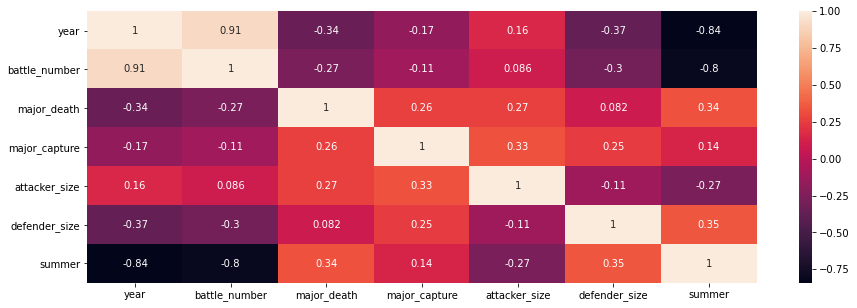

In [42]:
### Corr heatmap analysis.
plt.figure(figsize=(15,5))
sns.heatmap(game.corr(),annot=True)
plt.show()

# Observation:
    There are no one values is highly correlation values is the data.

In [43]:
game.corr().style.background_gradient(cmap='Reds')

,year,battle_number,major_death,major_capture,attacker_size,defender_size,summer
year,1.000000,0.906781,-0.341050,-0.166234,0.155841,-0.366048,-0.841912
battle_number,0.906781,1.000000,-0.270421,-0.105225,0.086418,-0.297730,-0.799090
major_death,-0.341050,-0.270421,1.000000,0.264464,0.267966,0.081815,0.337136
major_capture,-0.166234,-0.105225,0.264464,1.000000,0.331961,0.249510,0.142112
attacker_size,0.155841,0.086418,0.267966,0.331961,1.000000,-0.112118,-0.273054
defender_size,-0.366048,-0.297730,0.081815,0.249510,-0.112118,1.000000,0.347108
summer,-0.841912,-0.799090,0.337136,0.142112,-0.273054,0.347108,1.000000


In [57]:
# count battle per Year
game.groupby('year')['battle_number'].count()

year
298     7
299    20
300    11
Name: battle_number, dtype: int64

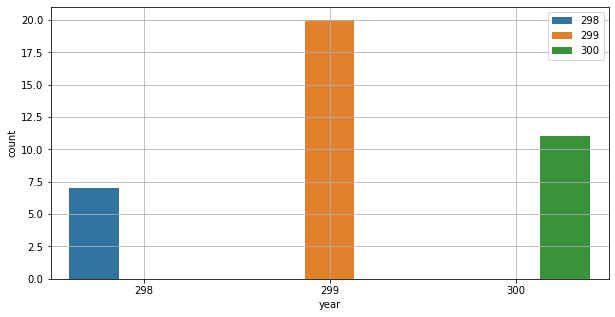

In [69]:
plt.figure(figsize=(10,5))
sns.countplot(data=game,x=game.year,hue='year')
plt.grid()
plt.legend()
plt.show()

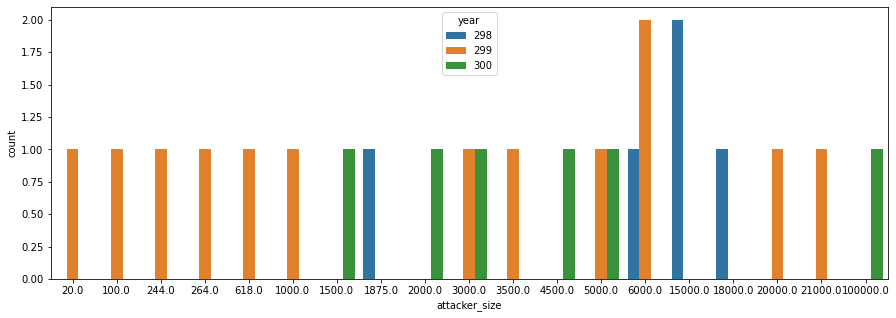

In [73]:
# count of the attacker size
plt.figure(figsize=(15,5))
sns.countplot(data=game,x=game.attacker_size,hue='year')
plt.show()

# Observation:
    There are max and constant values lies in the 299 Year and Max attacker_size count is 6000.
    In year of 300 counts are similar. and 298 year maximum values attacker_size is 15000.

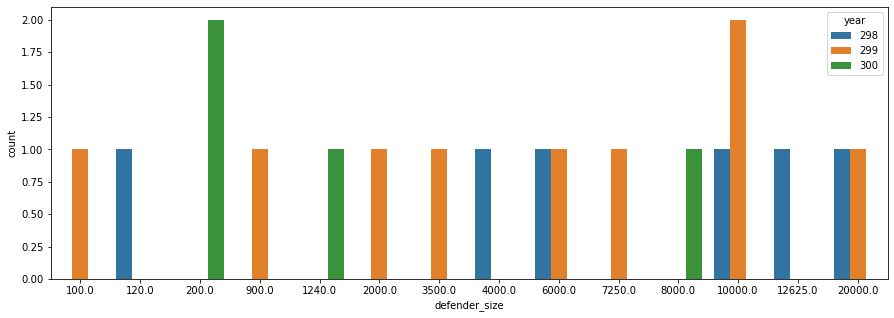

In [74]:
# count of the defender size
plt.figure(figsize=(15,5))
sns.countplot(data=game,x=game.defender_size,hue='year')
plt.show()

# Observation:
    Max counts are in defender in 300 year with ~2 with 200.0 defender size. and in 299 year ~2 with 10000.0 defender size.

# Read other related similar data

In [75]:
game2 = pd.read_csv(r"C:\Users\RAJAT SAHU\Desktop\DataScirce\GameOfThrone\character-deaths.csv")
game2.head(3)

,Name,Allegiances,Death Year,Book of Death,Death Chapter,Book Intro Chapter,Gender,Nobility,GoT,CoK,SoS,FfC,DwD
0,Addam Marbrand,Lannister,NaN,NaN,NaN,56.0,1,1,1,1,1,1,0
1,Aegon Frey (Jinglebell),None,299.0,3.0,51.0,49.0,1,1,0,0,1,0,0
2,Aegon Targaryen,House Targaryen,NaN,NaN,NaN,5.0,1,1,0,0,0,0,1


In [76]:
# check data type and observe is there null fector and values lies or not
game2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917 entries, 0 to 916
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                917 non-null    object 
 1   Allegiances         917 non-null    object 
 2   Death Year          305 non-null    float64
 3   Book of Death       307 non-null    float64
 4   Death Chapter       299 non-null    float64
 5   Book Intro Chapter  905 non-null    float64
 6   Gender              917 non-null    int64  
 7   Nobility            917 non-null    int64  
 8   GoT                 917 non-null    int64  
 9   CoK                 917 non-null    int64  
 10  SoS                 917 non-null    int64  
 11  FfC                 917 non-null    int64  
 12  DwD                 917 non-null    int64  
dtypes: float64(4), int64(7), object(2)
memory usage: 93.3+ KB


In [78]:
#change columns
game2 = game2.rename(columns={"Death Year":"DeathYear","Book of Death":"BookOfDeath","Death Chapter":"DeathChapter","Book Intro Chapter":"BookIntroChapter"})
game2.head()

,Name,Allegiances,DeathYear,BookOfDeath,DeathChapter,BookIntroChapter,Gender,Nobility,GoT,CoK,SoS,FfC,DwD
0,Addam Marbrand,Lannister,NaN,NaN,NaN,56.0,1,1,1,1,1,1,0
1,Aegon Frey (Jinglebell),None,299.0,3.0,51.0,49.0,1,1,0,0,1,0,0
2,Aegon Targaryen,House Targaryen,NaN,NaN,NaN,5.0,1,1,0,0,0,0,1
3,Adrack Humble,House Greyjoy,300.0,5.0,20.0,20.0,1,1,0,0,0,0,1
4,Aemon Costayne,Lannister,NaN,NaN,NaN,NaN,1,1,0,0,1,0,0


In [81]:
# find some duplicate
game2.duplicated().sum()

0

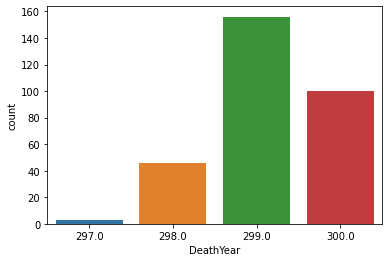

In [83]:
sns.countplot(data=game2,x=game2.DeathYear)
plt.show()

In [85]:
game.head(2)

,name,year,battle_number,attacker_king,defender_king,attacker_1,attacker_2,attacker_3,attacker_4,defender_1,...,major_death,major_capture,attacker_size,defender_size,attacker_commander,defender_commander,summer,location,region,note
0,Battle of the Golden Tooth,298,1,Joffrey/Tommen Baratheon,Robb Stark,Lannister,NaN,NaN,NaN,Tully,...,1.0,0.0,15000.0,4000.0,Jaime Lannister,"Clement Piper, Vance",1.0,Golden Tooth,The Westerlands,NaN
1,Battle at the Mummer's Ford,298,2,Joffrey/Tommen Baratheon,Robb Stark,Lannister,NaN,NaN,NaN,Baratheon,...,1.0,0.0,NaN,120.0,Gregor Clegane,Beric Dondarrion,1.0,Mummer's Ford,The Riverlands,NaN


Attacker unique king is data : ['Joffrey/Tommen Baratheon' 'Robb Stark' 'Balon/Euron Greyjoy'
 'Stannis Baratheon' nan]


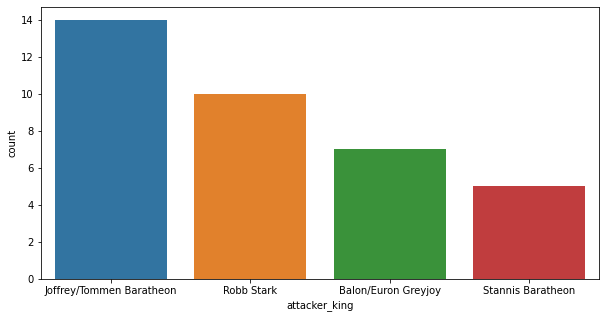

In [95]:
print("Attacker unique king is data :",game.attacker_king.unique())
plt.figure(figsize=(10,5))
sns.countplot(data=game,x='attacker_king')
plt.show()

# Observation:
    One the best winner king of game is Joffrey/Tommen Baratheon and loser is Stannis Baratheon

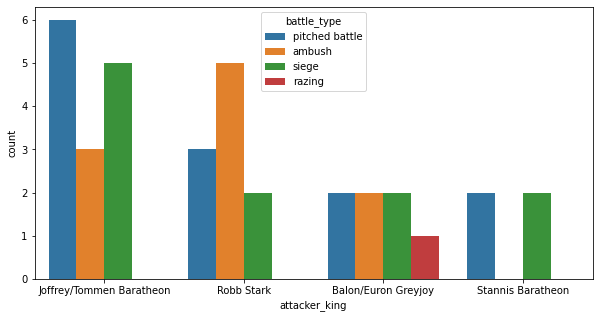

In [99]:
#find attacker based on the battle type.
plt.figure(figsize=(10,5))
sns.countplot(data=game,x='attacker_king',hue='battle_type')
plt.show()

In [105]:
Dgame = game[['defender_size','attacker_size','attacker_outcome']].dropna()

In [106]:
Dgame.head(1)

,defender_size,attacker_size,attacker_outcome
0,4000.0,15000.0,win


In [107]:
Dgame.reset_index(inplace=True)

In [108]:
Dgame.head(2)

,index,defender_size,attacker_size,attacker_outcome
0,0,4000.0,15000.0,win
1,2,10000.0,15000.0,win


In [109]:
Dgame.isnull().sum()

index               0
defender_size       0
attacker_size       0
attacker_outcome    0
dtype: int64

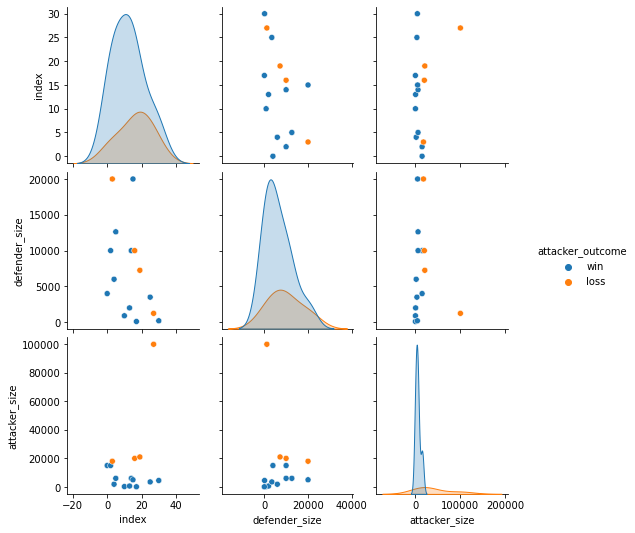

In [111]:
sns.pairplot(data=Dgame,hue='attacker_outcome')

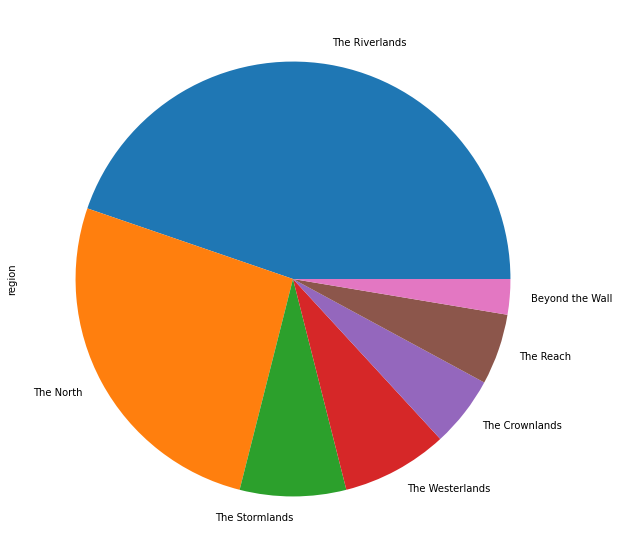

In [120]:
plt.figure(figsize=(15,10))
game['region'].value_counts().plot(kind='pie')
plt.show()

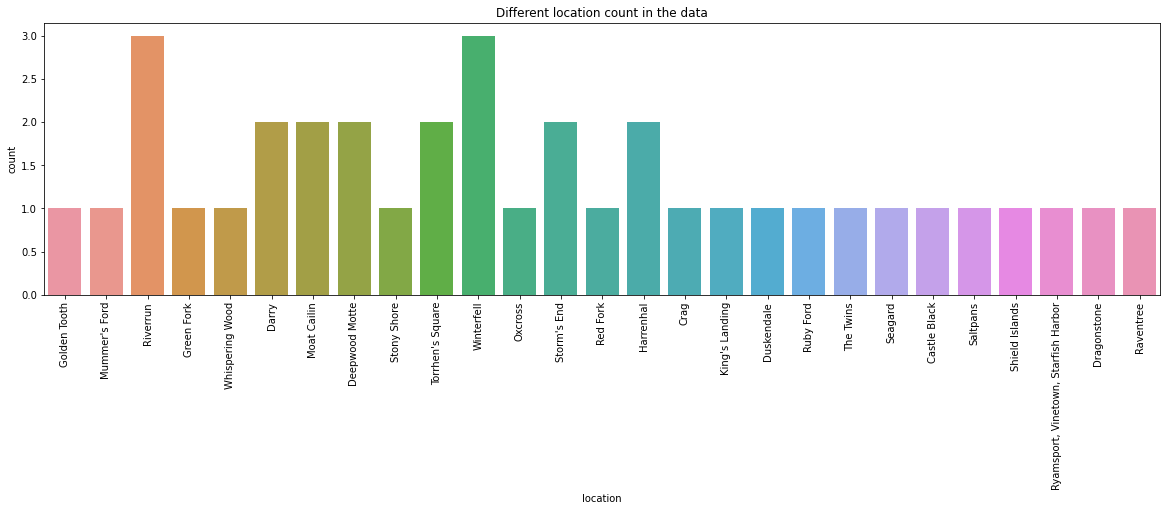

In [131]:
plt.figure(figsize=(20,5))
sns.countplot(x=game['location'])
plt.xticks(rotation=90)
plt.title("Different location count in the data")
plt.show()

In [132]:
game2.head()

,Name,Allegiances,DeathYear,BookOfDeath,DeathChapter,BookIntroChapter,Gender,Nobility,GoT,CoK,SoS,FfC,DwD
0,Addam Marbrand,Lannister,NaN,NaN,NaN,56.0,1,1,1,1,1,1,0
1,Aegon Frey (Jinglebell),None,299.0,3.0,51.0,49.0,1,1,0,0,1,0,0
2,Aegon Targaryen,House Targaryen,NaN,NaN,NaN,5.0,1,1,0,0,0,0,1
3,Adrack Humble,House Greyjoy,300.0,5.0,20.0,20.0,1,1,0,0,0,0,1
4,Aemon Costayne,Lannister,NaN,NaN,NaN,NaN,1,1,0,0,1,0,0


In [149]:
# Using Seaborn Fuction

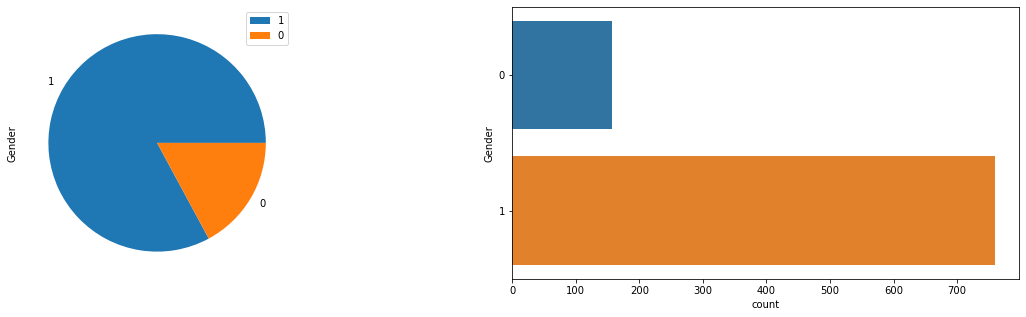

In [189]:
plt.figure(figsize=(20,5))
plt.subplot(121)
game2['Gender'].value_counts().plot(kind='pie')
plt.legend(game2['Gender'].unique())
plt.subplot(122)
sns.countplot(data=game2,y=game2.Gender)
plt.xticks()
plt.show()

In [148]:
# Using Matplotlib Fuction

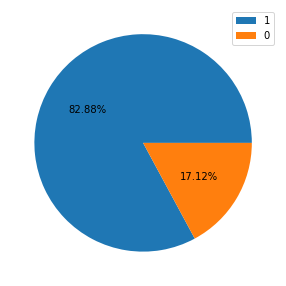

In [154]:
plt.figure(figsize=(20,5))
plt.pie(game2['Gender'].value_counts(),autopct="%0.2f%%")
plt.legend(game2['Gender'].unique())
plt.show()

# Observation:
    Male: 82.88% and 17.12% is Female
    1    760
    0    157
    Name: Gender, dtype: int64

In [156]:
game.head(2)

,name,year,battle_number,attacker_king,defender_king,attacker_1,attacker_2,attacker_3,attacker_4,defender_1,...,major_death,major_capture,attacker_size,defender_size,attacker_commander,defender_commander,summer,location,region,note
0,Battle of the Golden Tooth,298,1,Joffrey/Tommen Baratheon,Robb Stark,Lannister,NaN,NaN,NaN,Tully,...,1.0,0.0,15000.0,4000.0,Jaime Lannister,"Clement Piper, Vance",1.0,Golden Tooth,The Westerlands,NaN
1,Battle at the Mummer's Ford,298,2,Joffrey/Tommen Baratheon,Robb Stark,Lannister,NaN,NaN,NaN,Baratheon,...,1.0,0.0,NaN,120.0,Gregor Clegane,Beric Dondarrion,1.0,Mummer's Ford,The Riverlands,NaN


In [175]:
game.defender_commander.head(10)

0                                 Clement Piper, Vance
1                                     Beric Dondarrion
2                        Edmure Tully, Tytos Blackwood
3    Tywin Lannister, Gregor Clegane, Kevan Lannist...
4                                      Jaime Lannister
5                     Lord Andros Brax, Forley Prester
6                                          Lyman Darry
7                                                  NaN
8                                                  NaN
9                                                  NaN
Name: defender_commander, dtype: object

In [172]:
def MaxDataColumn(df):
    count = []
    for i in df:
        c = str(i).split(',')
        C = len(c)
        count.append(C)
    return max(count)

In [173]:
df = game.defender_commander
MaxDataColumn(df)

7

In [190]:
game.head(2)

,name,year,battle_number,attacker_king,defender_king,attacker_1,attacker_2,attacker_3,attacker_4,defender_1,...,major_death,major_capture,attacker_size,defender_size,attacker_commander,defender_commander,summer,location,region,note
0,Battle of the Golden Tooth,298,1,Joffrey/Tommen Baratheon,Robb Stark,Lannister,NaN,NaN,NaN,Tully,...,1.0,0.0,15000.0,4000.0,Jaime Lannister,"Clement Piper, Vance",1.0,Golden Tooth,The Westerlands,NaN
1,Battle at the Mummer's Ford,298,2,Joffrey/Tommen Baratheon,Robb Stark,Lannister,NaN,NaN,NaN,Baratheon,...,1.0,0.0,NaN,120.0,Gregor Clegane,Beric Dondarrion,1.0,Mummer's Ford,The Riverlands,NaN


In [191]:
game2.head(2)

,Name,Allegiances,DeathYear,BookOfDeath,DeathChapter,BookIntroChapter,Gender,Nobility,GoT,CoK,SoS,FfC,DwD
0,Addam Marbrand,Lannister,NaN,NaN,NaN,56.0,1,1,1,1,1,1,0
1,Aegon Frey (Jinglebell),None,299.0,3.0,51.0,49.0,1,1,0,0,1,0,0


C:\Users\RAJAT SAHU\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


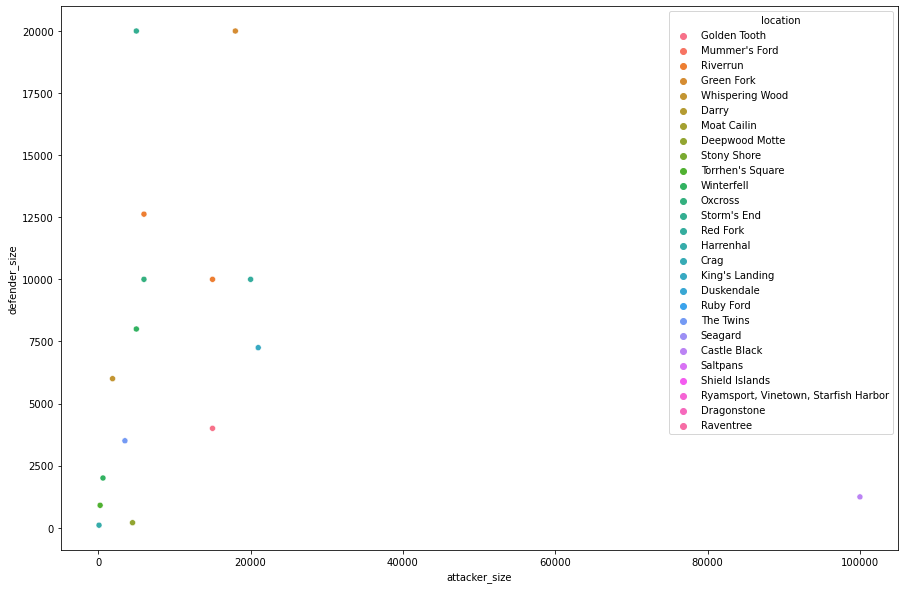

In [195]:
plt.figure(figsize=(15,10))
sns.scatterplot('attacker_size','defender_size',hue='location',data=game)
plt.show()

In [196]:
game.loc[game.attacker_size == max(game.attacker_size)]

,name,year,battle_number,attacker_king,defender_king,attacker_1,attacker_2,attacker_3,attacker_4,defender_1,...,major_death,major_capture,attacker_size,defender_size,attacker_commander,defender_commander,summer,location,region,note
27,Battle of Castle Black,300,28,Stannis Baratheon,Mance Rayder,Free folk,Thenns,Giants,NaN,Night's Watch,...,1.0,1.0,100000.0,1240.0,"Mance Rayder, Tormund Giantsbane, Harma Dogshe...","Stannis Baratheon, Jon Snow, Donal Noye, Cotte...",0.0,Castle Black,Beyond the Wall,NaN
